Kích thước tensor đầu vào Fi: (540, 899, 3)
H = 540 , W = 899 , C_in = 3


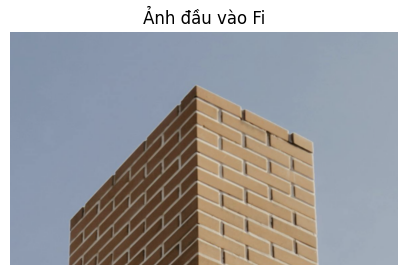

Kích thước tensor lọc K: (3, 3, 3, 2)
Kích thước ảnh sau padding: (542, 901, 3)


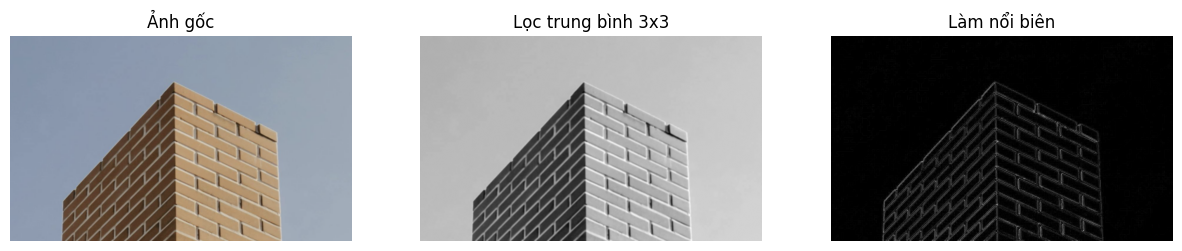

Sai khác lớn nhất giữa code tự cài đặt và cv2.filter2D: 0.033551186
Cần kiểm tra lại: sai khác còn lớn.


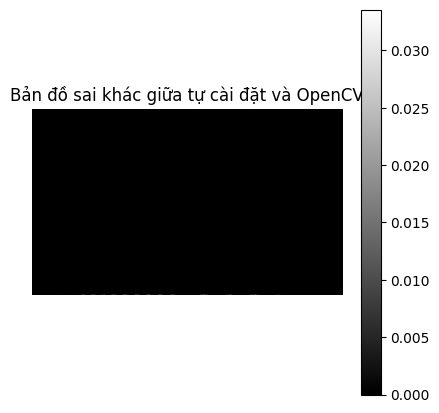

In [5]:
# ============================================================
# GIÁO TRÌNH: THỊ GIÁC MÁY: TỪ XỬ LÝ ẢNH ĐẾN HỌC SÂU
# BÀI CODE MINH HỌA: Lọc tuyến tính bằng cửa sổ trượt
# Chương/Mục liên quan: 4.1.1 - Lọc tuyến tính trong miền không gian
# Công thức minh họa: (4.1), (4.2), (4.3)
# ============================================================

# ============================================================
# MÔ TẢ
# ============================================================

# Mục đích:
# - Minh họa phép lọc tuyến tính trên ảnh màu bằng cửa sổ trượt.
# - Cài đặt trực tiếp công thức tích chập bằng vòng for.
# - Giúp người học thấy rõ mỗi điểm ảnh đầu ra được tính từ lân cận của ảnh đầu vào.

# Input:
# - Ảnh màu chimney.png từ GitHub.
# - Ảnh được đọc ở dạng RGB và chuẩn hóa về [0, 1].

# Output:
# - Ảnh gốc.
# - Ảnh sau lọc trung bình 3x3.
# - Ảnh sau lọc làm nổi biên.
# - Sai khác giữa kết quả tự cài đặt và OpenCV để kiểm tra tính đúng đắn.

# Lưu ý:
# Đoạn code này được xây dựng với sự hỗ trợ của công cụ AI.
# Giảng viên đã đọc, kiểm tra và hiệu chỉnh nhằm bảo đảm tính chính xác,
# tính sư phạm và sự phù hợp với nội dung lý thuyết trong giáo trình.

# Người học không chỉ chạy code để xem kết quả, mà cần hiểu:
# - Code đang minh họa nội dung lý thuyết nào;
# - Các bước xử lý tương ứng với công thức hoặc thuật toán nào;
# - Kết quả đầu ra có hợp lý hay không;
# - Khi thay đổi tham số, kết quả thay đổi như thế nào.

# ============================================================
# 1. CÀI ĐẶT VÀ IMPORT THƯ VIỆN
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# ============================================================
# 2. TẢI DỮ LIỆU ĐẦU VÀO
# ============================================================

url = "https://github.com/lthavnu/cv-book/raw/main/images/chimney.png"
image_path = "chimney.png"

urllib.request.urlretrieve(url, image_path)

img_bgr = cv2.imread(image_path, cv2.IMREAD_COLOR)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Chuẩn hóa ảnh về miền [0, 1] để thuận tiện tính toán
Fi = img_rgb.astype(np.float32) / 255.0

H, W, C_in = Fi.shape

print("Kích thước tensor đầu vào Fi:", Fi.shape)
print("H =", H, ", W =", W, ", C_in =", C_in)

# ============================================================
# 3. HIỂN THỊ ẢNH ĐẦU VÀO
# ============================================================

plt.figure(figsize=(5, 5))
plt.imshow(Fi)
plt.title("Ảnh đầu vào Fi")
plt.axis("off")
plt.show()

# ============================================================
# 4. XỬ LÝ CHÍNH
# ============================================================

# ------------------------------------------------------------
# 4.1. Định nghĩa tensor lọc K
# ------------------------------------------------------------

# Với ảnh màu, tensor đầu vào có dạng:
# Fi ∈ R^{H x W x C_in}

# Tensor lọc có dạng:
# K ∈ R^{(2a+1) x (2b+1) x C_in x C_out}

# Ở đây dùng cửa sổ 3x3 nên:
# a = b = 1

a = 1
b = 1
kernel_size = 2 * a + 1

C_out = 2

# Kênh đầu ra 0: lọc trung bình 3x3
mean_kernel = np.ones((3, 3), dtype=np.float32) / 9.0

# Kênh đầu ra 1: lọc làm nổi biên
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=np.float32)

# Khởi tạo tensor lọc K
K = np.zeros((kernel_size, kernel_size, C_in, C_out), dtype=np.float32)

# Mỗi bộ lọc được áp dụng giống nhau cho từng kênh màu
for c in range(C_in):
    K[:, :, c, 0] = mean_kernel
    K[:, :, c, 1] = edge_kernel

# Chia cho C_in để khi cộng qua các kênh màu, biên độ không bị tăng quá mạnh
K = K / C_in

print("Kích thước tensor lọc K:", K.shape)

# ------------------------------------------------------------
# 4.2. Padding ảnh đầu vào
# ------------------------------------------------------------

# Để tính được tại vùng biên, ta thêm padding cho ảnh.
# Ở đây dùng padding phản xạ để hạn chế tạo viền đen.

Fi_pad = np.pad(
    Fi,
    pad_width=((a, a), (b, b), (0, 0)),
    mode="reflect"
)

print("Kích thước ảnh sau padding:", Fi_pad.shape)

# ------------------------------------------------------------
# 4.3. Cài đặt công thức (4.3) bằng vòng for
# ------------------------------------------------------------

# Công thức (4.3):
# Fo(x, y, c_out) =
#     sum_c sum_u sum_v Fi(x-u, y-v, c) K(u, v, c, c_out)

Fo = np.zeros((H, W, C_out), dtype=np.float32)

# Vòng for theo vị trí điểm ảnh đầu ra
for x in range(H):
    for y in range(W):

        # Vòng for theo kênh đầu ra c_out
        for c_out in range(C_out):

            total = 0.0

            # Vòng for theo kênh đầu vào c
            for c in range(C_in):

                # Vòng for theo tọa độ cửa sổ lọc u, v
                for u in range(-a, a + 1):
                    for v in range(-b, b + 1):

                        # Do ảnh đã padding nên vị trí trong ảnh pad là x+a, y+b
                        # Biểu thức dưới đây tương ứng với Fi(x-u, y-v, c)
                        pixel_value = Fi_pad[x + a - u, y + b - v, c]

                        # Đưa u, v từ miền [-a, a], [-b, b] về chỉ số mảng [0, 2a], [0, 2b]
                        weight = K[u + a, v + b, c, c_out]

                        # Cộng tích có trọng số
                        total += pixel_value * weight

            Fo[x, y, c_out] = total

# Tách hai ảnh đầu ra
img_mean = Fo[:, :, 0]
img_edge = Fo[:, :, 1]

# Đưa kết quả về miền hiển thị [0, 1]
img_mean_show = np.clip(img_mean, 0, 1)
img_edge_show = np.clip(np.abs(img_edge), 0, 1)

# ============================================================
# 5. HIỂN THỊ KẾT QUẢ
# ============================================================

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Fi)
plt.title("Ảnh gốc")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_mean_show, cmap="gray")
plt.title("Lọc trung bình 3x3")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_edge_show, cmap="gray")
plt.title("Làm nổi biên")
plt.axis("off")

plt.show()

# ============================================================
# 6. KIỂM TRA KẾT QUẢ
# ============================================================

# Do mean_kernel đối xứng nên tích chập và tương quan cho cùng kết quả.
# Ta so sánh kết quả tự cài đặt với cv2.filter2D.

gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

mean_cv2 = cv2.filter2D(gray, ddepth=-1, kernel=mean_kernel, borderType=cv2.BORDER_REFLECT)

# Kết quả img_mean ở trên là lọc ảnh màu rồi cộng qua các kênh.
# Để so sánh công bằng, ta lọc ảnh xám bằng cùng cách tự cài đặt.

gray_pad = np.pad(gray, pad_width=((a, a), (b, b)), mode="reflect")
mean_manual_gray = np.zeros((H, W), dtype=np.float32)

for x in range(H):
    for y in range(W):
        total = 0.0
        for u in range(-a, a + 1):
            for v in range(-b, b + 1):
                total += gray_pad[x + a - u, y + b - v] * mean_kernel[u + a, v + b]
        mean_manual_gray[x, y] = total

max_error = np.max(np.abs(mean_manual_gray - mean_cv2))

print("Sai khác lớn nhất giữa code tự cài đặt và cv2.filter2D:", max_error)

if max_error < 1e-5:
    print("Kiểm tra đúng: kết quả tự cài đặt gần như trùng với OpenCV.")
else:
    print("Cần kiểm tra lại: sai khác còn lớn.")

# Hiển thị ảnh sai khác
plt.figure(figsize=(5, 5))
plt.imshow(np.abs(mean_manual_gray - mean_cv2), cmap="gray")
plt.title("Bản đồ sai khác giữa tự cài đặt và OpenCV")
plt.axis("off")
plt.colorbar()
plt.show()

# ============================================================
# 7. GỢI Ý THỬ NGHIỆM CHO NGƯỜI HỌC
# ============================================================

# 1. Thay mean_kernel 3x3 bằng bộ lọc trung bình 5x5.
#    Khi đó cần đặt a = b = 2 và kernel_size = 5.

# 2. Thay edge_kernel bằng các bộ lọc khác, ví dụ Sobel theo phương x hoặc y.

# 3. Thử bỏ phép chia K = K / C_in để quan sát ảnh hưởng khi cộng qua nhiều kênh màu.

# 4. Thay mode="reflect" trong np.pad bằng mode="constant" để quan sát ảnh hưởng của padding tại biên ảnh.